# Direct Wind Magnet Layout:

# Working Version:

Rads:
[2.17, 2.4400000000000004, 2.71]


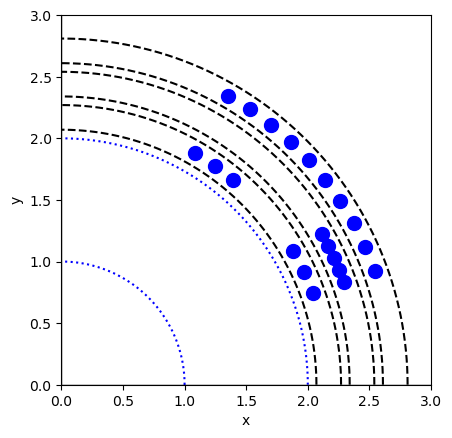

In [5]:
import numpy as np
from iminuit import Minuit
from iminuit.cost import UnbinnedNLL
from scipy.stats import norm
import panel as pn
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
# Sets the floats to round instead of going into scientific notation
np.set_printoptions(suppress=True, formatter={'float_kind':'{:0.6f}'.format})

# Need to be able to do this for mutiple groups, so different angular bounds at same rad
def plotter(lower, upper, rad, point_num): # Need to find a way to not have them evenly dispersed through the radius, need them side-by-side
    # Iterate through lower and upper angle bounds, with some dphi that determines the spacing
    phi_list = np.linspace(np.deg2rad(lower), np.deg2rad(upper), point_num) # Enter in degrees
    x = rad*np.cos(phi_list)
    y = rad*np.sin(phi_list)
    return x, y

def circ_plot(rad, color='k--'):
    circ = np.linspace(0, 2*np.pi, 500)
    x = rad * np.cos(circ)
    y = rad * np.sin(circ)
    plt.plot(x, y, color, zorder=1)

# The field defined in terms of the harmonics
def B_harm(x, y, x_a, y_a, I):
    # Position of the conductor
    a = np.hypot(x_a, y_a)
    
    # Position of field measurement
    r = np.hypot(x, y)

    # Angle between a and y=0
    phi = np.arctan2(y_a, x_a)
    # Angle between r and y=0
    theta = np.arctan2(y, x)

    # Angle between r and a
    ang = phi - theta

    # Replace r=0 with r=1e-20 to avoid divsion by zero
    r = np.where(r == 0, 1e-10, r)

    # Now we compute the field for both cases, adding up harmonics until the n_max harmonic is calculated and added

    # Case for r < a:
    B_r_in = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(r / a)**(n - 1) * np.sin(n * ang) for n in range(1, n_max+1)], axis=0)
    B_theta_in = (-1)*((mu0 * I) / (2 * np.pi * a)) * np.sum([(r / a)**(n - 1) * np.cos(n * ang) for n in range(1, n_max+1)], axis=0)
    
    # Case for r > a:
    B_r_out = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(a / r)**(n + 1) * np.sin(n * ang) for n in range(0, n_max+1)], axis=0)
    B_theta_out = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(a / r)**(n + 1) * np.cos(n * ang) for n in range(0, n_max+1)], axis=0)

    # Use np.where to select the correct field values to return
    # np.where(cond., x, y) -> If true, takes x; if false, takes y
    B_r = np.where(r > a, B_r_out, B_r_in)
    B_theta = np.where(r > a, B_theta_out, B_theta_in)

    # Convert to cartesian coordinates (notably using the angle theta, not ang)
    B_x = B_r * np.cos(theta) - B_theta * np.sin(theta)
    B_y = B_r * np.sin(theta) + B_theta * np.cos(theta)

    return B_x, B_y



# User defined varaiables

# Max n values for field calculation
n_max = 10
# Radius of aperture
aper_rad = 2 
# Min angle from the x-axis for the first block in each layer
min_ang = 20
# Radial spacing
dr = 0.1 
# Thickness of spacing between layers
t = 0.07 
# Reference radius
ref_rad = 1

# Needs to be implemented still
# Type of magnet: 1=dipole, 2=quadrupole, 3=sextupole
mag_type = 1
# Current magnitude
I0 = 1000

# Defined variables

# Vacuum permeability
mu0 = 4 * np.pi * 1e-7 
# Radius of the first layer, based on aperture radius
init_rad = aper_rad + dr 


# Right now, points are distributed uniformly over the angular region, thus, angular spacing between points is not controlled by the user
# spacing = [ [], [], [] ]

# TO-DO:
# Angles can be calulated from equation for a number of blocks
# Then we want to specify the spacing between blocks instead of the angle they take up
# Then, we can optimize this spacing to determine the optimal field through the reference radius

# This contains the dphi for each block
# For n blocks we have n+1 spaces to worry about


# A list specifying the configuration of each layer:
# [ [conductors], [angular range of block] ]
layers = [ 
                [ [3, 3], [ (min_ang, 30), (50,60) ] ], # Layer 1
                [ [5], [ (min_ang, 30) ] ], # Layer 2
                [ [10], [ (min_ang, 60) ] ] # Layer 3
         ]

# Dipole example
# layers = [ 
#                 [ [10], [ (min_ang, 85) ] ], # Layer 1
#                 [ [8], [ (min_ang, 85) ] ], # Layer 2
#                 [ [6], [ (min_ang, 85) ] ] # Layer 3
#          ]

# Can add a wire param list here, so that the loop assigns a current based on the block
# Keep track of blocks by having a counter and then checking the parity of that counter as it goes to decide the sign of the current
# Have a wire params list that I add the current term to

# Arrays of the x and y values per layer
x_quad1 = []
y_quad1 = []
# A list of radii to plot based on the layer spacing:
rads = []
# Loops over each layer
for i, layer in enumerate(layers): # Goes from 1-3
    # Radii at which points are plotted, depends only on the layer we are on
    rads.append(init_rad+(2*i*dr) + (i+1)*t) 
    # Loops over the second list in each layer
    for j, ang_list in enumerate(layer[1]):
        # Calulates the x and y values of each conductor for that blocks given angles
        # Accounts for the spacing between the layers, layer[0][j] is the number of conductors
        x, y = plotter(ang_list[0], ang_list[1], init_rad+(2*i*dr) + (i+1)*t, layer[0][j])  
        x_quad1.append(x)
        y_quad1.append(y)




# Concatenation puts them all into just one list
x_totq1 = np.concatenate(x_quad1)
y_totq1 = np.concatenate(y_quad1)

# Reflect values to each quadrant:

# Q2
x_totq2 = -1*x_totq1
y_totq2 = y_totq1
# Q3
x_totq3 = -1*x_totq1
y_totq3 = -1*y_totq1
# Q4
x_totq4 = x_totq1
y_totq4 = -1*y_totq1
# Concatenate all these lists to make a total list of x and y values
x_tot = np.concatenate( (x_totq1, x_totq2, x_totq3, x_totq4) )
y_tot = np.concatenate( (y_totq1, y_totq2, y_totq3, y_totq4) )

print("Rads:")
print(rads)

# Bounds set here
all_quads = False

if all_quads:
    # Bounds for all four quadrants:
    bounds =  [ [-3, 3], [-3, 3] ]
elif not all_quads:
    # Bounds for first quadrant only:
    bounds =  [ [0, 3], [0, 3] ]


# MAGNETIC FIELD CALCULATION (WORKS) - Right now, only uses a constant current amplitude

"""
# Grid setup (for plotting the field)
# The field is always calculated everywhere in this region
x = np.linspace(bounds[0][0], bounds[0][1], 250)
y = np.linspace(bounds[1][0], bounds[1][1], 250)
X, Y = np.meshgrid(x, y)

Bx_total = np.zeros_like(X)
By_total = np.zeros_like(Y)

for xa, ya in zip(x_tot, y_tot):
    Bx, By = B_harm(X, Y, xa, ya, -16000)
    Bx_total += Bx
    By_total += By

# Total B-field magnitudes are computed
B_mag = np.hypot(Bx_total, By_total)
# Plots the magnetic field lines
strm = plt.streamplot(X, Y, Bx_total, By_total, color=B_mag, cmap='viridis', density=3, zorder=0)
cbar = plt.colorbar(strm.lines, label='Magnetic Field Magnitude (T)')
"""



######################################## PLOTTING ##############################################
# Plots circles around \pm dr awway from where the conductors are (offset by t as done above)
for rad in rads:
    circ_plot(rad+dr)
    circ_plot(rad-dr)

# Aperture Radius
circ_plot(aper_rad, color='b:')
# Reference Radius
circ_plot(ref_rad, color='b:')
# Plot of all the x and y values (represents where all the conductors are)
plt.plot(x_tot, y_tot, 'o', color="blue", markersize = 10)

plt.xlim(bounds[0][0], bounds[0][1])
plt.ylim(bounds[1][0], bounds[1][1])
plt.xlabel("x")
plt.ylabel("y")
plt.axhline(0, color='black', linewidth=1, zorder=1)
plt.axvline(0, color='black', linewidth=1, zorder=1)
plt.gca().set_aspect('equal')
plt.show()